Image Noise Addition and Filtering Techniques: Concepts and Code Implementation

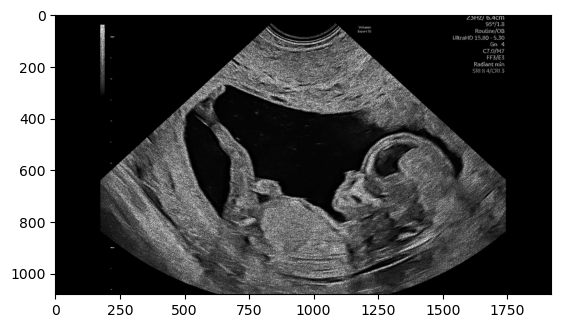

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_speckle_noise(image, intensity=0.5):
    noise = np.random.randn(*image.shape) * intensity
    noisy_image = image + image * noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

image = cv2.imread("ultrasound.png", cv2.IMREAD_GRAYSCALE)
noisy_image = add_speckle_noise(image, 0.6)
plt.imshow(noisy_image, cmap='gray')
plt.show()

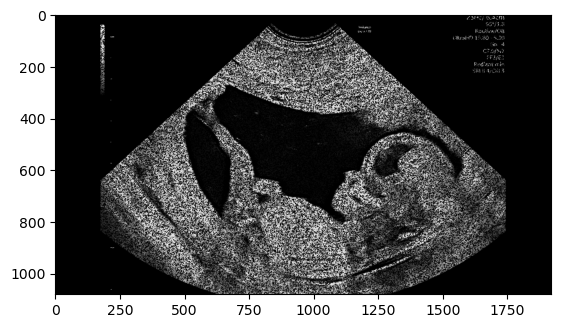

In [6]:
def geometric_mean_filter(image, kernel_size=3):
    m, n = kernel_size, kernel_size
    padded_image = cv2.copyMakeBorder(image, m//2, m//2, n//2, n//2, cv2.BORDER_REFLECT)
    filtered_image = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_image[i:i+m, j:j+n]
            filtered_image[i, j] = np.prod(region)**(1.0/(m*n))
    return filtered_image.astype(np.uint8)

filtered_image = geometric_mean_filter(noisy_image, 3)
plt.imshow(filtered_image, cmap='gray')
plt.show()

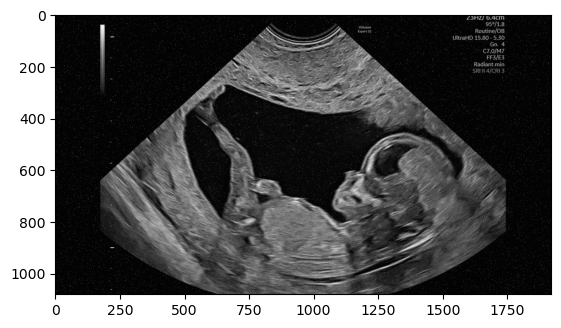

In [7]:
def add_salt_and_gaussian_noise(image, salt_prob=0.01, sigma=10):
    noisy_image = image.copy()
    num_salt = np.ceil(salt_prob * image.size * 0.5)
    coords = [np.random.randint(0, i, int(num_salt)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255
    noisy_image = noisy_image + np.random.normal(0, sigma, image.shape)
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

noisy_image = add_salt_and_gaussian_noise(image)
plt.imshow(noisy_image, cmap='gray')
plt.show()

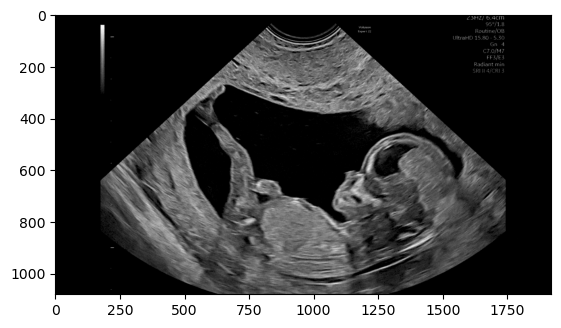

In [8]:
def harmonic_mean_filter(image, kernel_size=3):
    m, n = kernel_size, kernel_size
    padded_image = cv2.copyMakeBorder(image, m//2, m//2, n//2, n//2, cv2.BORDER_REFLECT)
    filtered_image = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_image[i:i+m, j:j+n].astype(np.float64)
            filtered_image[i, j] = (m * n) / np.sum(1.0 / (region + 1e-5))
    return np.clip(filtered_image, 0, 255).astype(np.uint8)

filtered_image = harmonic_mean_filter(noisy_image, 3)
plt.imshow(filtered_image, cmap='gray')
plt.show()

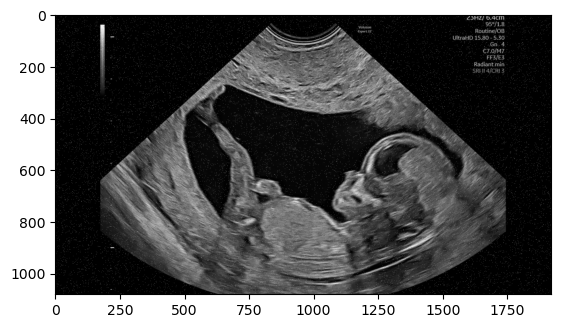

In [11]:
def add_salt_and_pepper_noise(image, prob=0.02):
    noisy_image = image.copy()
    num_noise = int(prob * image.size)
    coords = [np.random.randint(0, i, num_noise) for i in image.shape]
    noisy_image[coords[0], coords[1]] = np.random.choice([0, 255], num_noise)
    return noisy_image

noisy_image = add_salt_and_pepper_noise(image)
plt.imshow(noisy_image, cmap='gray')
plt.show()

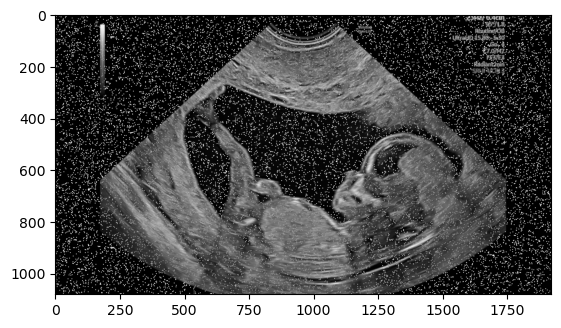

In [12]:
def contra_harmonic_mean_filter(image, Q=1.5, kernel_size=3):
    m, n = kernel_size, kernel_size
    padded_image = cv2.copyMakeBorder(image, m//2, m//2, n//2, n//2, cv2.BORDER_REFLECT)
    filtered_image = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_image[i:i+m, j:j+n].astype(np.float64)
            num = np.sum(region ** (Q + 1))
            denom = np.sum(region ** Q) + 1e-5
            filtered_image[i, j] = num / denom
    return np.clip(filtered_image, 0, 255).astype(np.uint8)

filtered_image = contra_harmonic_mean_filter(noisy_image, Q=1.5, kernel_size=3)
plt.imshow(filtered_image, cmap='gray')
plt.show()